# Predicción del Salario de un Beisbolista en función de su rendimiento

#### Aplicamos AdaBoosting y Gradient Boosting


In [1]:
# Importar las librerias

# Cargamos nuestras librerias
import numpy as np
import pandas as pd

# Entorno SciKit Learn
from sklearn.tree import DecisionTreeRegressor   # Algortimo CART para árboles.

from sklearn.model_selection import train_test_split  # Dividir el conjunto de prueba y entrenamiento
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score # Validación cruzada
from sklearn.model_selection import cross_validate # Validación cruzada
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

# Para preprocesamiento
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler  # La libreria para reescalar datos
import matplotlib.pyplot as plt

In [2]:
datos=pd.read_csv("hitters.csv")

In [3]:
datos.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [5]:
# Filtramos solo del 263 casos de beisbolistas donde se conoce el salario
datos=datos[np.isnan(datos.Salary)!=True]

In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64

# Análisis de los outliers en el Salario

{'whiskers': [<matplotlib.lines.Line2D at 0x162f34a53d0>,
 'caps': [<matplotlib.lines.Line2D at 0x162f34a5910>,
 'boxes': [<matplotlib.lines.Line2D at 0x162f34a5130>],
 'medians': [<matplotlib.lines.Line2D at 0x162f34a5e50>],
 'fliers': [<matplotlib.lines.Line2D at 0x162f34b8130>],
 'means': []}

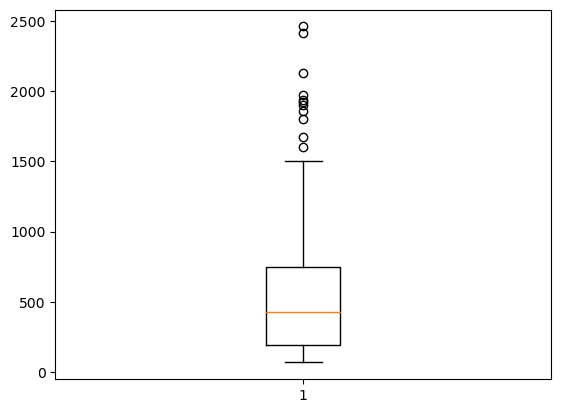

In [7]:
plt.boxplot(datos["Salary"])

In [8]:
# Eliminamos los outliers
datos["Salary"].describe()

count     263.000000
mean      535.925882
std       451.118681
min        67.500000
25%       190.000000
50%       425.000000
75%       750.000000
max      2460.000000
Name: Salary, dtype: float64

In [9]:
datos=datos[datos["Salary"]<=750+1.5*(750-190)]  # Eliminamos los datos atípicos

{'whiskers': [<matplotlib.lines.Line2D at 0x162f3521c40>,
 'caps': [<matplotlib.lines.Line2D at 0x162f3532130>,
 'boxes': [<matplotlib.lines.Line2D at 0x162f35219a0>],
 'medians': [<matplotlib.lines.Line2D at 0x162f3532670>],
 'fliers': [<matplotlib.lines.Line2D at 0x162f3532910>],
 'means': []}

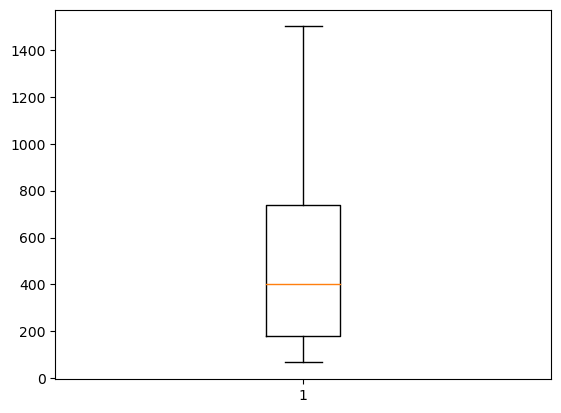

In [10]:
plt.boxplot(datos["Salary"])

In [11]:
#Definimos los atributos y el Target
y=datos.Salary
del datos["Salary"]
X=datos


In [12]:
#Recodificar las variables de tipo Objeto.

datos["League"].replace({"A":0,"N":1}, inplace=True)
datos["Division"].replace({"E":0,"W":1}, inplace=True)
datos["NewLeague"].replace({"A":0,"N":1}, inplace=True)

In [13]:
datos.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,1,1,632,43,10,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,0,1,880,82,14,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,1,0,200,11,3,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,1,0,805,40,4,1
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,0,1,282,421,25,0


In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 252 entries, 1 to 321
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   AtBat      252 non-null    int64
 1   Hits       252 non-null    int64
 2   HmRun      252 non-null    int64
 3   Runs       252 non-null    int64
 4   RBI        252 non-null    int64
 5   Walks      252 non-null    int64
 6   Years      252 non-null    int64
 7   CAtBat     252 non-null    int64
 8   CHits      252 non-null    int64
 9   CHmRun     252 non-null    int64
 10  CRuns      252 non-null    int64
 11  CRBI       252 non-null    int64
 12  CWalks     252 non-null    int64
 13  League     252 non-null    int64
 14  Division   252 non-null    int64
 15  PutOuts    252 non-null    int64
 16  Assists    252 non-null    int64
 17  Errors     252 non-null    int64
 18  NewLeague  252 non-null    int64
dtypes: int64(19)
memory usage: 39.4 KB


# Calibración del Algoritmo

#### Con Bagging 

In [15]:
# Sin outliers y con 50 métricas para la estimación del desempeño...
# n_estimators=10.
# La mejor configuración fue: {'max_depth': 5, 'max_features': 0.5, 'max_samples': 0.5, 'min_samples_leaf': 9}
# La mejor métrica es: 198.95073590162036

### Con AdaBoosting

In [16]:
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor

In [17]:
modelo=AdaBoostRegressor()
c_v=RepeatedKFold(n_splits=10,n_repeats=5)
scores=cross_val_score(modelo,X,y,scoring="neg_root_mean_squared_error",cv=c_v,n_jobs=-1)
print("La raiz cuadrada del error cuadrático promedio es {:.3f}+/- {:.3f}".format(-scores.mean(),
                                                                                 scores.std()))

La raiz cuadrada del error cuadrático promedio es 220.878+/- 34.202


In [18]:
modelo=GradientBoostingRegressor()
c_v=RepeatedKFold(n_splits=10,n_repeats=5)
scores=cross_val_score(modelo,X,y,scoring="neg_root_mean_squared_error",cv=c_v,n_jobs=-1)
print("La raiz cuadrada del error cuadrático promedio es {:.3f}+/- {:.3f}".format(-scores.mean(),
                                                                                 scores.std()))

La raiz cuadrada del error cuadrático promedio es 205.288+/- 42.431


In [ ]:
# Calibración de los hiperparámetros de GradientBoosting
espacio_parametral={"learning_rate":[0.01,0.05,0.1,0.12],
                   "max_leaf_nodes":[2,3,4,5,6,8,12,14,26,28,20,24,30]}

modelo=GradientBoostingRegressor()
modelo_candidatos=GridSearchCV(modelo,param_grid=espacio_parametral,
                               scoring="neg_root_mean_squared_error",cv=c_v,n_jobs=-1)
modelo_candidatos.fit(X,y)

print("La mejor configuración es ", modelo_candidatos.best_params_)
print("La mejor métrica ", -modelo_candidatos.best_score_)

In [19]:
# Con GradientBoosting logramos mejorar el desempeño de los algortimos Bagging, AdaBoosting. 
# RMSE= 194.71.    learning_rate=0.12, max_leaf_nodes=2

In [ ]:
# Validación cruzada anidada
# Calibración de los hiperparámetros de GradientBoosting
espacio_parametral={"learning_rate":[0.01,0.05,0.1,0.12],
                   "max_leaf_nodes":[2,3,4,5,6,8,12,14,26,28,20,24,30]}

modelo=GradientBoostingRegressor()
modelo_candidatos=GridSearchCV(modelo,param_grid=espacio_parametral,
                               scoring="neg_root_mean_squared_error",cv=10,n_jobs=-1)
scores=cross_val_score(modelo_candidatos,X,y,scoring="neg_root_mean_squared_error",cv=c_v,n_jobs=-1 )

print("La mejor métrica ", -scores.mean())

In [20]:
# Ajustar el modelo final...
# Ocupamos todos los datos
modelo_final=GradientBoostingRegressor(learning_rate=0.12, max_leaf_nodes=2)
modelo_final.fit(X,y)  #<-Este modelo entrenado ya me sirve para hacer las predicciones

GradientBoostingRegressor(learning_rate=0.12, max_leaf_nodes=2)

In [21]:
# Como hacemos las predicciones
datos_nuevos=pd.DataFrame({'AtBat':[570], 'Hits':[150], 'HmRun':[10], 'Runs':[100], 'RBI':[80],
                           'Walks':[30],'Years':[8], 'CAtBat':[800],'CHits':[490], 'CHmRun':[50],
                           'CRuns':[245],'CRBI':[213], 'CWalks':[160], 'League':[1], 'Division':[0],
                           'PutOuts':[300],'Assists':[188], 'Errors':[4], 'NewLeague':[0]})

In [22]:
datos_nuevos

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,NewLeague
0,570,150,10,100,80,30,8,800,490,50,245,213,160,1,0,300,188,4,0


In [23]:
modelo_final.predict(datos_nuevos)

array([541.31073414])

# Algoritmo XGBoosting

In [24]:
from xgboost import XGBRegressor  # Para clasificación es XGBClassifier

modelo=XGBRegressor()
c_v=RepeatedKFold(n_splits=10,n_repeats=5)
scores=cross_val_score(modelo,X,y,scoring="neg_root_mean_squared_error",cv=10,n_jobs=-1)
print("La raiz cuadrada del error cuadrático promedio es {:.3f}+/- {:.3f}".format(-scores.mean(),
                                                                                 scores.std()))

La raiz cuadrada del error cuadrático promedio es 221.340+/- 35.073


In [26]:
# Calibración de los hiperparámetros de XGBoosting
espacio_parametral={"learning_rate":[0.01,0.05,0.1,0.12],
                    "colsample_bytree": [0.6,0.8,0.9],  # <- Porcentaje de atributos para construir cada arbol
                    "max_depth":[3,4,5,6,8]}

modelo=XGBRegressor()
modelo_candidatos=GridSearchCV(modelo,param_grid=espacio_parametral,
                               scoring="neg_root_mean_squared_error",cv=c_v,n_jobs=-1)
modelo_candidatos.fit(X,y)

print("La mejor configuración es ", modelo_candidatos.best_params_)
print("La mejor métrica ", -modelo_candidatos.best_score_)

La mejor configuración es  {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 3}
La mejor métrica  199.65300262970726
